<a href="https://colab.research.google.com/github/hitomitsu50/Sports_data_portfolio_MLB_Statcast/blob/main/2025%E5%B9%B4Statcast%E3%83%95%E3%82%A9%E3%83%BC%E3%82%B7%E3%83%BC%E3%83%A0_%E3%82%B9%E3%83%88%E3%83%A9%E3%82%A4%E3%82%AF%E7%8E%87TOP10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#ライブラリのインストール
!pip install pybaseball japanize_matplotlib
!sudo apt-get -y update
!sudo apt-get -y install fonts-ipaexfont

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 37.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 426.1/426.1 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 432.7/432.7 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 63.7 MB/s eta 0:00:00
  Created wheel for japanize_matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=db417264664fecd5c62d07ed128d35c75f2fc2d06176edcf6597da4e2f09aa80
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize_matplotlib
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:5 https://r2u.stat.illinois.edu/ubun

In [ ]:
#ライブラリのインポート
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import japanize_matplotlib
import time
import glob
from pybaseball import statcast

In [ ]:
#データの読み出しと結合
#ファイル名パターンに一致するＣＳＶを取得
csv_files_pattern=("sample_data/statcast_*.csv")
csv_files=glob.glob(csv_files_pattern)

In [ ]:
#ＣＳＶファイルデータの読み込みとリストに格納
dfs=[]
for file in csv_files:
  try:
    df_month=pd.read_csv(file)
    dfs.append(df_month)
    print(f"{file}を読み込みました。")
  except Exception as e:
    print(f"{file}を読み込み中にエラーが発生:{e}")

sample_data/statcast_2025-08-01-2025-08-31.csvを読み込みました。
sample_data/statcast_2025-05-01-2025-05-31.csvを読み込みました。
sample_data/statcast_2025-09-01-2025-09-28.csvを読み込みました。
sample_data/statcast_2025-04-01-2025-04-30.csvを読み込みました。
sample_data/statcast_2025-03-18-2025-03-31.csvを読み込みました。
sample_data/statcast_2025-06-01-2025-06-30.csvを読み込みました。
sample_data/statcast_2025-07-01-2025-07-31.csvを読み込みました。


In [ ]:
#ＣＳＶファイルのデータ結合
if dfs:
  df_combined=pd.concat(dfs,ignore_index=True)
  df=df_combined #dfに格納
  print("全てのデータを結合しました。")
  display(df.head())
  print(f"結合後の行数 :{len(df)}")
else:
  print("読み込めるＣＳＶファイルが見つかりませんでした。")

全てのデータを結合しました。


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2025-08-31,96.8,-1.30,5.69,"Iglesias, Raisel",681082,628452,strikeout,foul_tip,...,1.0,1.15,0.70,-0.70,35.6,0.836799,32.074654,18.179462,44.557031,5.901987
1,FF,2025-08-31,96.5,-2.37,5.08,"Iglesias, Raisel",681082,628452,NaN,called_strike,...,1.0,1.24,0.88,-0.88,22.4,NaN,NaN,NaN,NaN,NaN
2,SI,2025-08-31,95.6,-1.35,5.66,"Iglesias, Raisel",681082,628452,NaN,called_strike,...,1.0,1.29,1.46,-1.46,34.2,NaN,NaN,NaN,NaN,NaN
3,FF,2025-08-31,95.8,-1.19,5.75,"Iglesias, Raisel",664056,628452,field_out,hit_into_play,...,1.0,1.03,0.56,0.56,35.7,9.598266,2.043193,20.982010,49.139945,29.610941
4,FF,2025-08-31,96.1,-1.24,5.74,"Iglesias, Raisel",664056,628452,NaN,foul,...,1.0,1.24,0.56,0.56,36.8,5.348509,9.026745,22.616372,41.165531,22.625864


結合後の行数 :742080


In [ ]:
#読み込まれた各ＣＳＶファイルの行数を確認
for file in csv_files:
  temp_df=pd.read_csv(file)
  print(f"{file}: {len(temp_df)} 行")

sample_data/statcast_2025-08-01-2025-08-31.csv: 124298 行
sample_data/statcast_2025-05-01-2025-05-31.csv: 120218 行
sample_data/statcast_2025-09-01-2025-09-28.csv: 110338 行
sample_data/statcast_2025-04-01-2025-04-30.csv: 114767 行
sample_data/statcast_2025-03-18-2025-03-31.csv: 49338 行
sample_data/statcast_2025-06-01-2025-06-30.csv: 115816 行
sample_data/statcast_2025-07-01-2025-07-31.csv: 107305 行


In [ ]:
# --- 1. フォーシーム(FF)かつ、判定ボール(ball)以外を抽出
strike_zone_results=["strike", "swinging_strike","called_strike","foul","hit_onto_play"]
df_4seam=df[(df["pitch_type"]== "FF")&(df["description"].isin(strike_zone_results))].copy()

In [ ]:
#2 --- 2. 指標の算出(１００球以上の投手に限定) ---
stats=df_4seam.groupby("player_name").agg(
    strike_count=("description", lambda x: x.isin(["swinging_strike","called_strike"]).sum()),
    total_pitches=("description","count")
).reset_index()
#100球以上
stats=stats[stats["total_pitches"]>=100].copy()
#ストライク率の計算
stats["strike_rate"]=stats["strike_count"]/stats["total_pitches"]

In [ ]:
# --- 3. 姓 名 表示 ---
def reformat_name(name):
  if "," in name:
    last,first=name.split(", ")
    return f"{first} {last}"
  return name

stats["player_name"]=stats["player_name"].apply(reformat_name)

/tmp/ipython-input-4026026009.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot=sns.barplot(data=top_10_strike, x="strike_rate",y="player_name",palette="viridis")


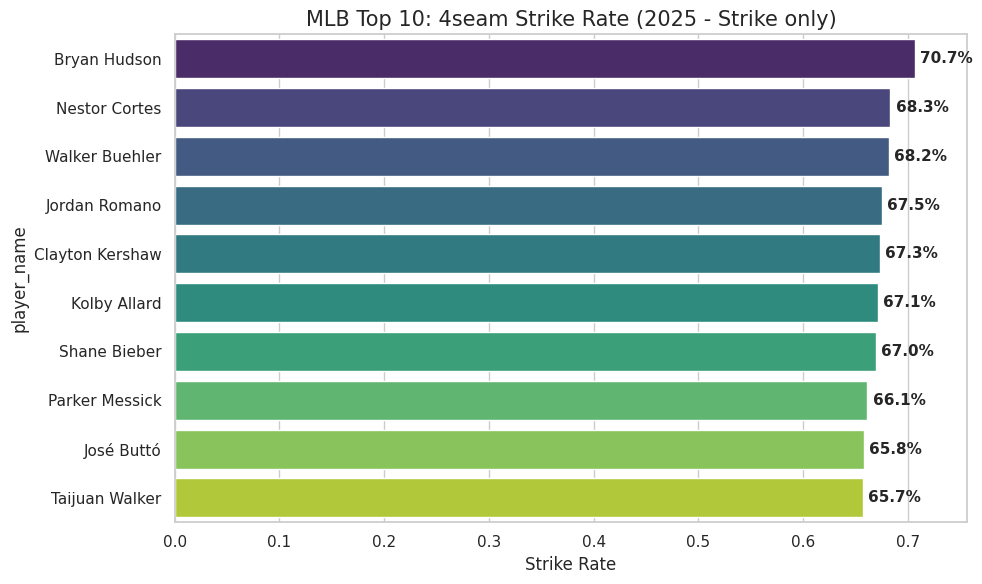

In [ ]:
# ---4. 可視化(ストライク率ランキング) ---
plt.figure(figsize=(10,6))
sns.set_theme(style="whitegrid")
#配色
top_10_strike=stats.sort_values("strike_rate",ascending=False).head(10)
plot=sns.barplot(data=top_10_strike, x="strike_rate",y="player_name",palette="viridis")
#数値と単位(%)を右側に表示
for p in plot.patches:
  width = p.get_width()
  plot.text(width + 0.005, p.get_y() + p.get_height()/2,f"{width:.1%}",
            va="center",fontweight="bold",fontsize=11)
plt.title("MLB Top 10: 4seam Strike Rate (2025 - Strike only)",fontsize=15)
plt.xlabel("Strike Rate")
plt.xlim(0, max(top_10_strike["strike_rate"]) + 0.05)
plt.tight_layout()
plt.show()

In [ ]:
# --- 5. テキスト出力 ---
print(f"---2025 MLB Four-Seam Analysis:Top 10 Strike Rate ---")
for index, row in top_10_strike.iterrows():
  print(f"{row["player_name"]} {row["strike_rate"]:.1%}")

---2025 MLB Four-Seam Analysis:Top 10 Strike Rate ---
Bryan Hudson 70.7%
Nestor Cortes 68.3%
Walker Buehler 68.2%
Jordan Romano 67.5%
Clayton Kershaw 67.3%
Kolby Allard 67.1%
Shane Bieber 67.0%
Parker Messick 66.1%
José Buttó 65.8%
Taijuan Walker 65.7%
